
# Capstone EDA Assignment

#### Overview

In this module, you will work on performing exploratory data analysis (EDA) to develop an initial report for your capstone project. You will use EDA to see what data can reveal beyond the formal modeling, hypothesis testing task, and data training to provide a better understanding of dataset variables and the relationships between them. You are encouraged to spend your time in this module cleaning your data and use feature engineering and EDA techniques to create visualizations to make sense of your findings. Additionally, you will also be required to use one of the ML algorithms you have learned so far in the program to develop a baseline model to use as a comparison in Module 24. You will have time in Module 24 to include additional models, clean the code, and make your work presentable for technical and non-technical audiences. For now, you will do the ‘heavy lifting’ of finding the answer to your research question.



# My Research

Question: Can we predict the performance of certain movie genres in the future based on performance via ratings and box office $$ of currently released movies?

## ORIGINAL datasets
1. Top Box Office Revenue Data for Top 1000 US and Top 1000 International Grossing movies https://www.kaggle.com/datasets/kalilurrahman/top-box-office-revenue-data-english-movies

  - Contains the Top 1000 US and Top 1000 International grossing movies

  - Includes movie titles, genres, lifetime gross earnings, and release year

  - Provides aggregated genre-level performance (total revenue and # of titles)

  - Useful for identifying high-earning genres and revenue trends over time


2. IMDB Movie Ratings: https://www.kaggle.com/datasets/preetviradiya/imdb-movies-ratings-details

  - Contains IMDb rating, Metascore, runtime, genres, number of votes, and gross revenue

  - Useful for measuring critical and audience reception

  - Includes multiple genres per movie, requiring parsing for analysis

  - Will be merged with box office data to link ratings with revenue

  
## NEW dataset
1. The Movies Dataset: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset/data?select=movies_metadata.csv
  - The dataset consists of movies released on or before July 2017.

  - Metadata on 45,000+ movies including budget, revenue, release dates, languages, production details, and genres

  - Includes additional files for cast/crew, plot keywords, ratings, etc.

  - Provides a much larger and richer dataset compared to our earlier merged sources

  - Enables stronger exploratory analysis and more reliable baseline modeling


Note: While the original merged datasets provided a good starting point, they were relatively small and limited in scope. Also confirmed this by performing a full EDA and modeling on the combination of the 2 original datasets. So, found this larger new dataset with various subsets that cover various aspects of the movie industry.

Note 2: Findings/analyses below will be in scope of the data provided i.e. movies released on or before July 2017


## Data loading + Cleaning

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

pd.set_option("display.max_columns", 100)
rand = 42

In [2]:
movies_meta = pd.read_csv("data/movies_metadata.csv", low_memory=False)
movies_meta = movies_meta[[
    "id","imdb_id","title","release_date",
    "budget","revenue","runtime","original_language","genres"
]]
movies_meta.head(3)

,id,imdb_id,title,release_date,budget,revenue,runtime,original_language,genres
0,862,tt0114709,Toy Story,1995-10-30,30000000,373554033.0,81.0,en,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,8844,tt0113497,Jumanji,1995-12-15,65000000,262797249.0,104.0,en,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,15602,tt0113228,Grumpier Old Men,1995-12-22,0,0.0,101.0,en,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ..."


In [3]:
movies_meta["release_date"] = pd.to_datetime(movies_meta["release_date"], errors="coerce")
movies_meta["release_year"] = movies_meta["release_date"].dt.year
movies_meta["release_month"] = movies_meta["release_date"].dt.month

for col in ["budget","revenue","runtime"]:
    movies_meta[col] = pd.to_numeric(movies_meta[col], errors="coerce")

# filter to English only
movies_meta = movies_meta[movies_meta["original_language"] == "en"].copy()

movies_meta["budget_log"] = np.log1p(movies_meta["budget"])
movies_meta["revenue_log"] = np.log1p(movies_meta["revenue"])

movies_meta[["budget","revenue","runtime","budget_log","revenue_log"]].describe().T

,count,mean,std,min,25%,50%,75%,max
budget,32269.0,5.609529e+06,2.030109e+07,0.0,0.0,0.0,0.0,3.800000e+08
revenue,32267.0,1.517192e+07,7.557805e+07,0.0,0.0,0.0,0.0,2.787965e+09
runtime,32261.0,9.313871e+01,3.711575e+01,0.0,85.0,93.0,105.0,1.256000e+03
budget_log,32269.0,3.579488e+00,6.672999e+00,0.0,0.0,0.0,0.0,1.975568e+01
revenue_log,32267.0,3.190528e+00,6.579251e+00,0.0,0.0,0.0,0.0,2.174858e+01


In [4]:
def extract_genre(x):
    try:
        x = str(x).replace("'", '"')
        genres = json.loads(x)
        if isinstance(genres, list) and len(genres) > 0:
            return genres[0]["name"]
    except:
        return None

movies_meta["genres_primary"] = movies_meta["genres"].apply(extract_genre)
movies_meta["genres_primary"].value_counts().head(10)

,count
genres_primary,
Drama,7505
Comedy,6333
Action,3287
Documentary,2927
Horror,2163
Crime,1241
Thriller,1209
Adventure,1130
Animation,759


In [5]:
credits = pd.read_csv(
    "data/credits.csv",
    engine="python",
    on_bad_lines="skip",
    encoding="utf-8",
    dtype={"id": str}
)
movies_meta["id"] = movies_meta["id"].astype(str)


In [6]:
# special merging logic since movies_meta["id"] is object & credits["id"] is int
def to_list(s):
    try:
        return json.loads(str(s).replace("'", '"'))
    except:
        return []

def get_director(crew):
    if isinstance(crew, list):
        for m in crew:
            if m.get("job") == "Director":
                return m.get("name")
    return None

def get_top_actor(cast):
    if isinstance(cast, list) and len(cast) > 0:
        return cast[0].get("name")
    return None

credits["crew_list"] = credits["crew"].apply(to_list)
credits["cast_list"] = credits["cast"].apply(to_list)
credits["director"] = credits["crew_list"].apply(get_director)
credits["top_actor"] = credits["cast_list"].apply(get_top_actor)

movies_meta = movies_meta.merge(
    credits[["id","director","top_actor"]],
    on="id",
    how="left"
)

movies_meta[["title","director","top_actor"]].head()


,title,director,top_actor
0,Toy Story,None,None
1,Jumanji,None,None
2,Grumpier Old Men,None,Walter Matthau
3,Waiting to Exhale,None,None
4,Father of the Bride Part II,None,Steve Martin


In [7]:
keywords = pd.read_csv(
    "data/keywords.csv",
    engine="python",
    on_bad_lines="skip",
    encoding="utf-8",
    dtype={"id": str}
)
movies_meta["id"] = movies_meta["id"].astype(str)


In [8]:
def to_list(s):
    try:
        return json.loads(str(s).replace("'", '"'))
    except:
        return []

def count_keywords(lst):
    return len(lst) if isinstance(lst, list) else 0

keywords["kw_list"] = keywords["keywords"].apply(to_list)
keywords["num_keywords"] = keywords["kw_list"].apply(count_keywords)

movies_meta = movies_meta.merge(
    keywords[["id","num_keywords"]],
    on="id",
    how="left"
)

movies_meta[["title","num_keywords"]].head()


,title,num_keywords
0,Toy Story,9
1,Jumanji,0
2,Grumpier Old Men,4
3,Waiting to Exhale,5
4,Father of the Bride Part II,9


In [9]:
movies_full = movies_meta.copy()
movies_full.head(3)

,id,imdb_id,title,release_date,budget,revenue,runtime,original_language,genres,release_year,release_month,budget_log,revenue_log,genres_primary,director,top_actor,num_keywords
0,862,tt0114709,Toy Story,1995-10-30,30000000.0,373554033.0,81.0,en,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",1995.0,10.0,17.216708,19.738573,Animation,None,None,9
1,8844,tt0113497,Jumanji,1995-12-15,65000000.0,262797249.0,104.0,en,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",1995.0,12.0,17.989898,19.386893,Adventure,None,None,0
2,15602,tt0113228,Grumpier Old Men,1995-12-22,0.0,0.0,101.0,en,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",1995.0,12.0,0.000000,0.000000,Romance,None,Walter Matthau,4


## EDA!

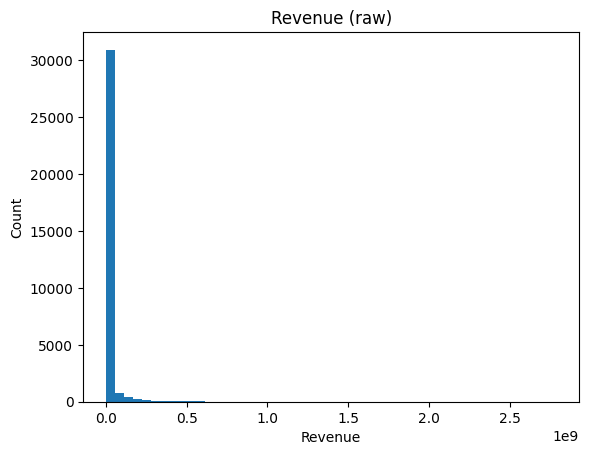

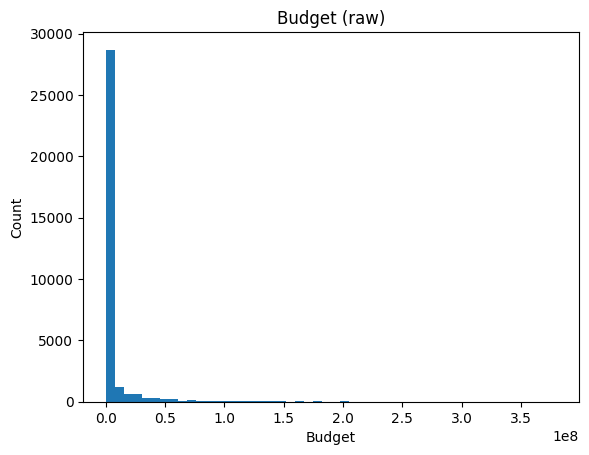

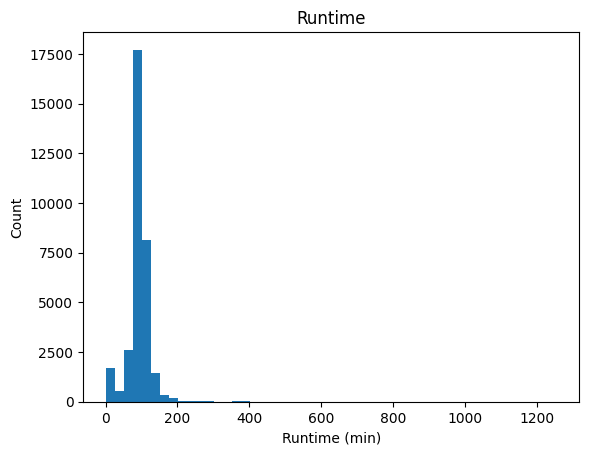

In [10]:
movies_full["revenue"].dropna().plot(kind="hist", bins=50, title="Revenue (raw)")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

movies_full["budget"].dropna().plot(kind="hist", bins=50, title="Budget (raw)")
plt.xlabel("Budget")
plt.ylabel("Count")
plt.show()

movies_full["runtime"].dropna().plot(kind="hist", bins=50, title="Runtime")
plt.xlabel("Runtime (min)")
plt.ylabel("Count")
plt.show()

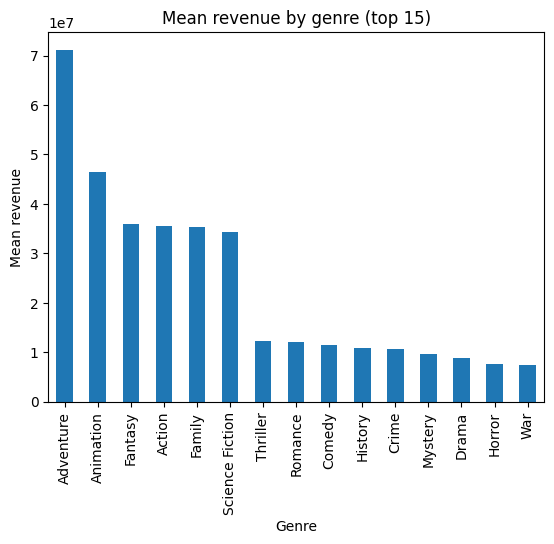

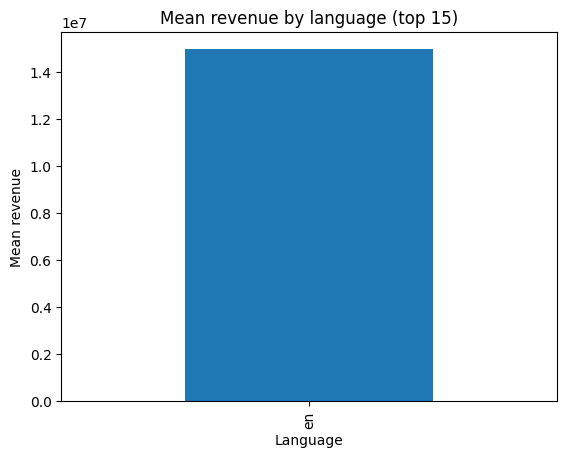

In [11]:
mean_rev_by_genre = movies_full.groupby("genres_primary")["revenue"].mean().sort_values(ascending=False).head(15)
mean_rev_by_genre.plot(kind="bar", title="Mean revenue by genre (top 15)")
plt.xlabel("Genre")
plt.ylabel("Mean revenue")
plt.show()

mean_rev_by_lang = movies_full.groupby("original_language")["revenue"].mean().sort_values(ascending=False).head(15)
mean_rev_by_lang.plot(kind="bar", title="Mean revenue by language (top 15)")
plt.xlabel("Language")
plt.ylabel("Mean revenue")
plt.show()

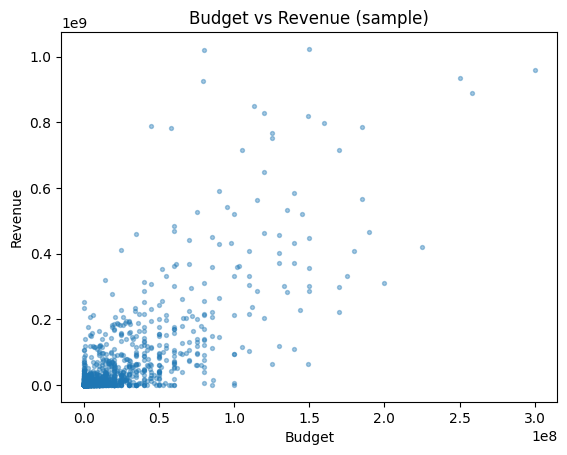

In [12]:
sample = movies_full[["budget","revenue"]].dropna().sample(n=min(5000, movies_full.shape[0]), random_state=rand)
plt.scatter(sample["budget"], sample["revenue"], s=8, alpha=0.4)
plt.title("Budget vs Revenue (sample)")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

## Modeling!

## Ridge, Random Forest, Linear, Lasso

In [13]:
target_category = "revenue"

numeric_features = [c for c in ["budget_log","runtime","release_year","release_month","num_keywords"] if c in movies_full.columns]
categorical_features = [c for c in ["genres_primary","director","top_actor"] if c in movies_full.columns]

df = movies_full.dropna(subset=[target_category]).copy()
x = df[numeric_features + categorical_features]
y = df[target_category]

x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2, random_state=rand)

print("train/valid:", x_train.shape, x_valid.shape)
print("numeric:", numeric_features)
print("categorical:", categorical_features)

train/valid: (26347, 8) (6587, 8)
numeric: ['budget_log', 'runtime', 'release_year', 'release_month', 'num_keywords']
categorical: ['genres_primary', 'director', 'top_actor']


In [14]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5))
])

preprocess = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

In [15]:
def fit_and_report(model, name):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    y_train_log = np.log1p(y_train)
    cv = cross_val_score(pipe, x_train, y_train_log, scoring="r2", cv=5)
    pipe.fit(x_train, y_train_log)
    y_pred = np.expm1(pipe.predict(x_valid))
    r2 = r2_score(y_valid, y_pred)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mae = mean_absolute_error(y_valid, y_pred)
    print(f"{name}:")
    print(f"  CV R²: {cv.mean():.3f} ± {cv.std():.3f}")
    print(f"  Validation R²: {r2:.3f}")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  MAE: ${mae:,.0f}")
    return {"cv_r2": cv.mean(), "validation_r2": r2, "rmse": rmse, "mae": mae}

In [16]:
ridge = Ridge(alpha=5.0, random_state=rand)
ridge_metrics = fit_and_report(ridge, "Ridge")

Ridge:
  CV R²: 0.506 ± 0.006
  Validation R²: -0.025
  RMSE: $70,300,214
  MAE: $14,700,566


In [17]:
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=4,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=rand
)
rf_metrics = fit_and_report(rf, "Random Forest")

Random Forest:
  CV R²: 0.582 ± 0.005
  Validation R²: 0.497
  RMSE: $49,265,665
  MAE: $10,664,588


In [18]:
lin = LinearRegression()
lin_reg_metrics = fit_and_report(lin, "Linear Regression")

lasso = Lasso(alpha=0.001, random_state=rand, max_iter=10000)
lasso_metrics = fit_and_report(lasso, "Lasso")

Linear Regression:
  CV R²: 0.506 ± 0.005
  Validation R²: -0.385
  RMSE: $81,711,405
  MAE: $15,361,250
Lasso:
  CV R²: 0.507 ± 0.006
  Validation R²: -0.026
  RMSE: $70,333,088
  MAE: $14,714,618


In [19]:
dt = DecisionTreeRegressor(random_state=rand)
dt_metrics = fit_and_report(dt, "Decision Tree")


Decision Tree:
  CV R²: 0.189 ± 0.010
  Validation R²: 0.235
  RMSE: $60,744,980
  MAE: $13,923,315


In [20]:
ridge_gs = GridSearchCV(
    Pipeline([("prep", preprocess), ("model", Ridge(random_state=rand))]),
    param_grid={"model__alpha": [0.1, 1, 5, 10, 50, 100]},
    scoring="r2",
    cv=5,
    n_jobs=-1
)
y_train_log = np.log1p(y_train)
ridge_gs.fit(x_train, y_train_log)
y_pred = np.expm1(ridge_gs.predict(x_valid))
ridge_gs_r2 = r2_score(y_valid, y_pred)
ridge_gs_rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
ridge_gs_mae = mean_absolute_error(y_valid, y_pred)
print("Ridge (GridSearchCV):")
print(f"  best alpha: {ridge_gs.best_params_['model__alpha']}")
print(f"  CV R²: {ridge_gs.best_score_:.3f}")
print(f"  Validation R²: {ridge_gs_r2:.3f}")
print(f"  RMSE: ${ridge_gs_rmse:,.0f}")
print(f"  MAE: ${ridge_gs_mae:,.0f}")
ridge_gs_metrics = {"cv_r2": ridge_gs.best_score_, "validation_r2": ridge_gs_r2, "rmse": ridge_gs_rmse, "mae": ridge_gs_mae}


Ridge (GridSearchCV):
  best alpha: 5
  CV R²: 0.506
  Validation R²: -0.025
  RMSE: $70,300,214
  MAE: $14,700,566


In [21]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=rand)
gradient_boost_metrics = fit_and_report(gbr, "Gradient Boosting")

rf_gs = GridSearchCV(
    Pipeline([("prep", preprocess), ("model", RandomForestRegressor(random_state=rand, n_jobs=-1))]),
    param_grid={
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 12, 24],
        "model__min_samples_split": [2, 4],
        "model__min_samples_leaf": [1, 2]
    },
    scoring="r2",
    cv=5,
    n_jobs=-1
)
y_train_log = np.log1p(y_train)
rf_gs.fit(x_train, y_train_log)
y_pred = np.expm1(rf_gs.predict(x_valid))
rf_gs_r2 = r2_score(y_valid, y_pred)
rf_gs_rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
rf_gs_mae = mean_absolute_error(y_valid, y_pred)
print("Random Forest (GridSearchCV):")
print(f"  best params: {rf_gs.best_params_}")
print(f"  CV R²: {rf_gs.best_score_:.3f}")
print(f"  Validation R²: {rf_gs_r2:.3f}")
print(f"  RMSE: ${rf_gs_rmse:,.0f}")
print(f"  MAE: ${rf_gs_mae:,.0f}")
rf_gs_metrics = {"cv_r2": rf_gs.best_score_, "validation_r2": rf_gs_r2, "rmse": rf_gs_rmse, "mae": rf_gs_mae}


Gradient Boosting:
  CV R²: 0.594 ± 0.008
  Validation R²: 0.384
  RMSE: $54,511,197
  MAE: $11,417,287
Random Forest (GridSearchCV):
  best params: {'model__max_depth': 12, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 400}
  CV R²: 0.594
  Validation R²: 0.490
  RMSE: $49,603,867
  MAE: $10,714,345


In [22]:
def fmt_usd(x): return f"${x:,.0f}"

print("Additional models:\n")

for name, m in [
    ("Ridge", ridge_metrics),
    ("Lasso", lasso_metrics),
    ("Linear Regression", lin_reg_metrics),
    ("Decision Tree", dt_metrics),
    ("Random Forest", rf_metrics),
    ("Gradient Boosting", gradient_boost_metrics),
    ("Ridge (GridSearchCV)", ridge_gs_metrics),
    ("Random Forest (GridSearchCV)", rf_gs_metrics)
]:
    print(f"{name}:")
    print(f"  CV R²: {m['cv_r2']:.3f}")
    print(f"  Validation R²: {m['validation_r2']:.3f}")
    print(f"  RMSE: {fmt_usd(m['rmse'])}")
    print(f"  MAE: {fmt_usd(m['mae'])}\n")


Additional models:

Ridge:
  CV R²: 0.506
  Validation R²: -0.025
  RMSE: $70,300,214
  MAE: $14,700,566

Lasso:
  CV R²: 0.507
  Validation R²: -0.026
  RMSE: $70,333,088
  MAE: $14,714,618

Linear Regression:
  CV R²: 0.506
  Validation R²: -0.385
  RMSE: $81,711,405
  MAE: $15,361,250

Decision Tree:
  CV R²: 0.189
  Validation R²: 0.235
  RMSE: $60,744,980
  MAE: $13,923,315

Random Forest:
  CV R²: 0.582
  Validation R²: 0.497
  RMSE: $49,265,665
  MAE: $10,664,588

Gradient Boosting:
  CV R²: 0.594
  Validation R²: 0.384
  RMSE: $54,511,197
  MAE: $11,417,287

Ridge (GridSearchCV):
  CV R²: 0.506
  Validation R²: -0.025
  RMSE: $70,300,214
  MAE: $14,700,566

Random Forest (GridSearchCV):
  CV R²: 0.594
  Validation R²: 0.490
  RMSE: $49,603,867
  MAE: $10,714,345



## More Visualizations

Note: This dataset is for movies released on or before July 2017. Graphs with year etc look like they "suddenly decline" but it's just because there's no data after July 2017.

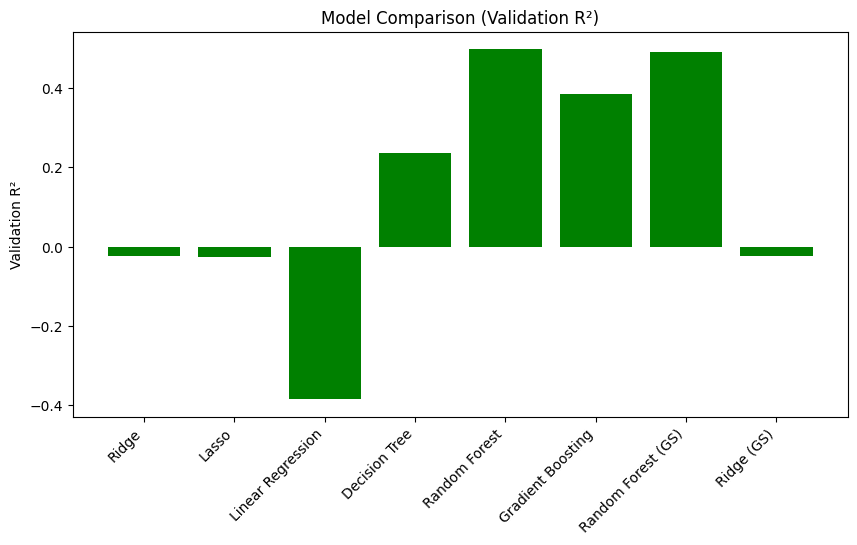

In [35]:
# Collect results into a DataFrame
results = pd.DataFrame([
    {"Model": "Ridge", "R2": ridge_metrics["validation_r2"], "RMSE": ridge_metrics["rmse"]},
    {"Model": "Lasso", "R2": lasso_metrics["validation_r2"], "RMSE": lasso_metrics["rmse"]},
    {"Model": "Linear Regression", "R2": lin_reg_metrics["validation_r2"], "RMSE": lin_reg_metrics["rmse"]},
    {"Model": "Decision Tree", "R2": dt_metrics["validation_r2"], "RMSE": dt_metrics["rmse"]},
    {"Model": "Random Forest", "R2": rf_metrics["validation_r2"], "RMSE": rf_metrics["rmse"]},
    {"Model": "Gradient Boosting", "R2": gradient_boost_metrics["validation_r2"], "RMSE": gradient_boost_metrics["rmse"]},
    {"Model": "Random Forest (GS)", "R2": rf_gs_metrics["validation_r2"], "RMSE": rf_gs_metrics["rmse"]},
    {"Model": "Ridge (GS)", "R2": ridge_gs_metrics["validation_r2"], "RMSE": ridge_gs_metrics["rmse"]},
])

# Bar plot for Validation R²
plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["R2"], color="green")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation R²")
plt.title("Model Comparison (Validation R²)")
plt.show()

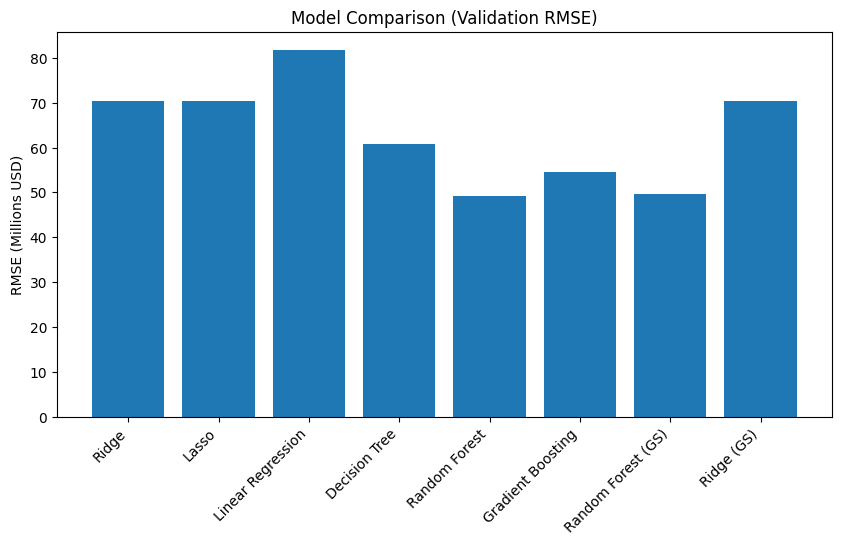

,Model,R2,RMSE
0,Ridge,-0.024998,7.030021e+07
1,Lasso,-0.025957,7.033309e+07
2,Linear Regression,-0.384761,8.171141e+07
3,Decision Tree,0.234702,6.074498e+07
4,Random Forest,0.496617,4.926566e+07
5,Gradient Boosting,0.383716,5.451120e+07
6,Random Forest (GS),0.489682,4.960387e+07
7,Ridge (GS),-0.024998,7.030021e+07


In [34]:
# Bar plot for RMSE
plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["RMSE"]/1e6) # scale into millions of $
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE (Millions USD)")
plt.title("Model Comparison (Validation RMSE)")
plt.show()

results


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

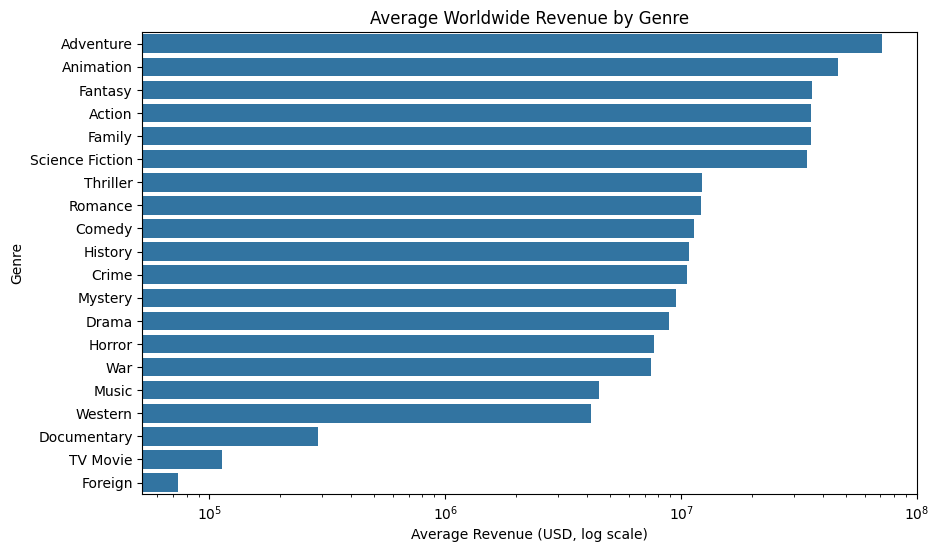

In [26]:
# Avg revenue by genre
genre_rev = (
    movies_full.groupby("genres_primary")["revenue"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_rev.values, y=genre_rev.index)
plt.xscale("log")
plt.xlabel("Average Revenue (USD, log scale)")
plt.ylabel("Genre")
plt.title("Average Worldwide Revenue by Genre")
plt.show()


**Analysis**
- Adventure, Animation, Fantasy, Action, and Science Fiction stand out as the **highest average revenue genres**.  
- Drama and Comedy, while very common in production volume, generate much lower average box office returns
   - May suggest that not all movies are necessarily made with the purpose of making money. Since directors have creative freedom etc, the goal/message/purpose of a film can totally depend on them and many other factors.
- Generally, movie studios continue to heavily invest in "blockbuster" genres because they consistently deliver the largest returns.  
- Also suggests that Adventure, Animation, Fantasty, Action, Family, and Sci-Fi were all major drivers and contributors to the success of the movie industry up until July 2017 (at least based on the data we have so far).
  - Would be interesting to check another dataset(s) just to confirm if this is still the case or if there have been any unexpected shifts

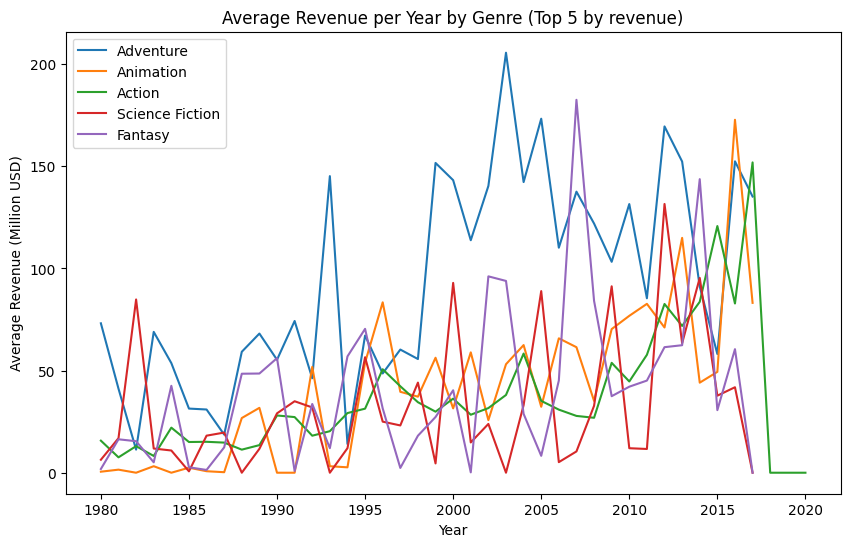

In [45]:
# Top 5 genres by average revenue
top_revenue_genres = (
    movies_full.dropna(subset=["genres_primary", "revenue", "release_year"])
    .query("release_year >= 1980")
    .groupby("genres_primary")["revenue"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

genre_rev_year = (
    movies_full.dropna(subset=["genres_primary", "release_year", "revenue"])
    .query("genres_primary in @top_revenue_genres and release_year >= 1980")
    .groupby(["release_year", "genres_primary"])["revenue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
for g in top_revenue_genres:
    subset = genre_rev_year[genre_rev_year["genres_primary"] == g]
    plt.plot(subset["release_year"], subset["revenue"]/1e6, label=g)

plt.xlabel("Year")
plt.ylabel("Average Revenue (Million USD)")
plt.title("Average Revenue per Year by Genre (Top 5 by revenue)")
plt.legend()
plt.show()


**Analysis**
- Adventure, Animation, Action, Science Fiction, and Fantasy are the top 5 genres by average revenue in our dataset (1980–2017).  
- Adventure has been the most dominant and consistently highest-grossing genre, peaking in the early 2000s with blockbuster franchises (e.g., *Harry Potter*, *Lord of the Rings*, *Pirates of the Caribbean*).  
- Animation shows a sharp rise post-2000, reflecting the boom of Disney and Pixar films in global markets.  
- Action and Science Fiction steadily grew in the 1990s and 2000s, driven by franchises like *Star Wars*, *Marvel*, and *Avatar*.  
- Fantasy revenue spiked in the 2000s–2010s but is more volatile compared to Adventure or Action.  
- The sharp drop post-2017 is not real decline—it reflects that our dataset ends mid-2017.  

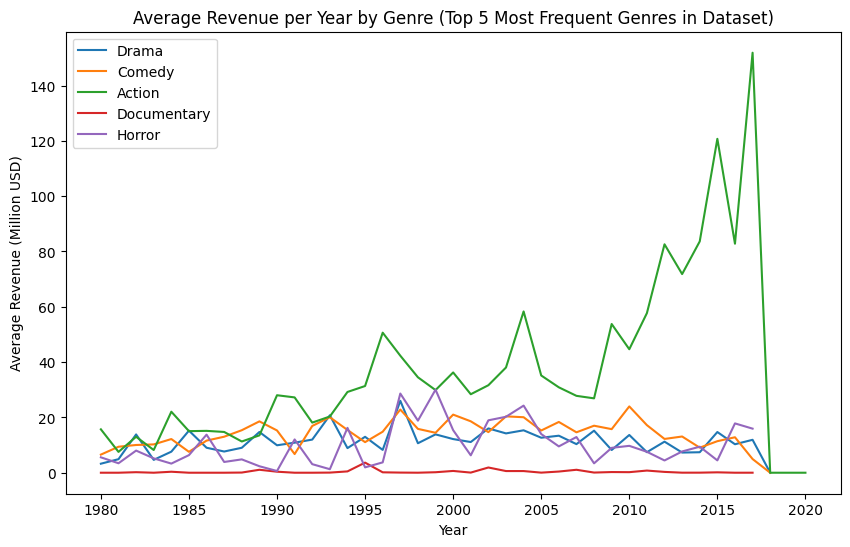

In [43]:
# Average revenue per year by top 5 genres in the dataset
top_genres = movies_full["genres_primary"].value_counts().head(5).index

genre_year = (
    movies_full.dropna(subset=["genres_primary", "release_year", "revenue"])
    .query("genres_primary in @top_genres and release_year >= 1980")
    .groupby(["release_year", "genres_primary"])["revenue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
for g in top_genres:
    subset = genre_year[genre_year["genres_primary"] == g]
    plt.plot(subset["release_year"], subset["revenue"]/1e6, label=g)

plt.xlabel("Year")
plt.ylabel("Average Revenue (Million USD)")
plt.title("Average Revenue per Year by Genre (Top 5 Most Frequent Genres in Dataset)")
plt.legend()
plt.show()


**Analysis**
- Drama, Comedy, Action, Documentary, and Horror are the top 5 genres and have been over the last 50 years or so
- Action  is consistently the growing and largest money-making genre
   - This is probably still true (note: our dataset is up to July 2017) - when I think about movies that are often advertised and make the news for box office sales etc, it's typically of the action genre
- Popular genres continue to shape future production of movies in terms of revenue
- Also note the difference between this graph and the prior one highlighting Top 5 genres by money-making It kind of gives some perspective into profitability vs the reality of the genres of movies that are made.
  - Many films are made in genres like Drama or Comedy, but the genres bringing in the biggest box office money-making are still categories like Adventure, Action, and Animation.  
  - This illustrates how production is still pretty closely shaped by profit; though movies of a variety of genres are made, filmmakers still invest heavily in those genres that have been shown to yield large revenues.


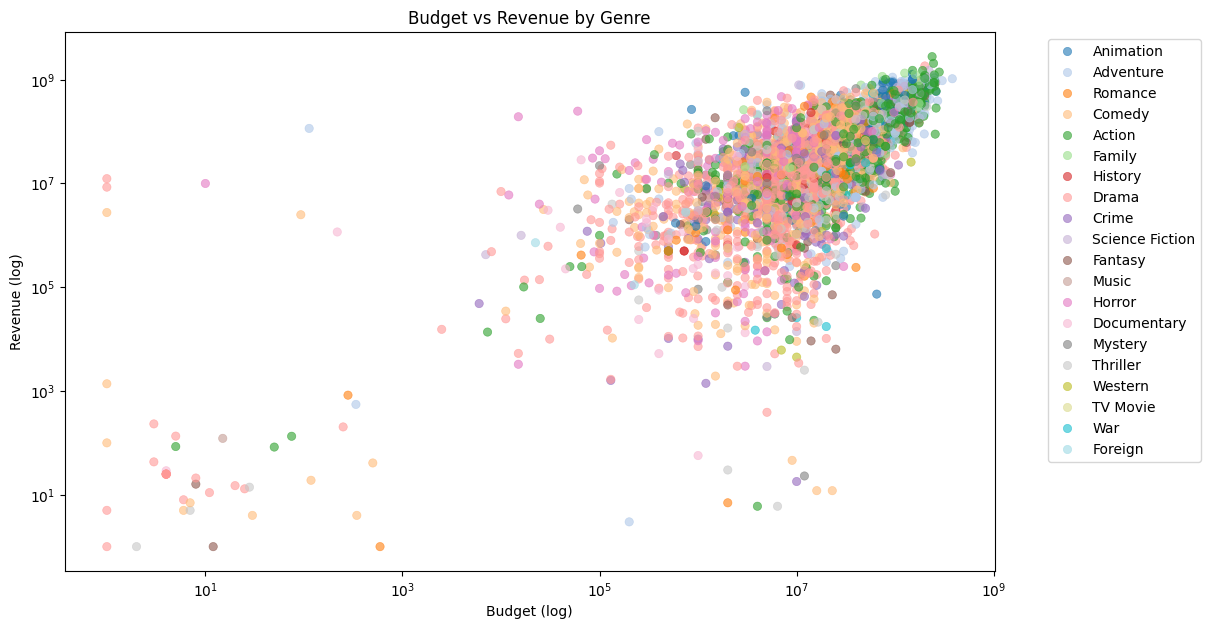

In [47]:
# Budget vs Revenue by genre with better colormap
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=movies_full, x="budget", y="revenue",
    hue="genres_primary", alpha=0.6, edgecolor=None,
    palette="tab20"   # more distinct colors for ease of digesting visual
)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Budget (log)")
plt.ylabel("Revenue (log)")
plt.title("Budget vs Revenue by Genre")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


**Analysis**
- There's a positive relationship between budget and revenue — higher budget films generally lead to higher revenues.  
- The clustering in the top-right indicates blockbuster films (both high budget + high revenue), are predominantly genres like Action, Adventure, and Animation.  
- At lower budgets - there’s a wider variance in revenue, with some low-budget films generating strong returns which are (outliers), while many struggle to  perform.  
- This suggests that while bigger budgets increase the likelihood of higher revenues, smaller films still occasionally have success (but this is not particularly predictable through this project, and requires more specific analysis)
- Though we color the genres, this is still plotting Budget against Revenue which suggests that the budget might have more influence (be a stronger predictor) on the revenue than just the genre alone.
   - This would be an interesting next step / thing to investigate

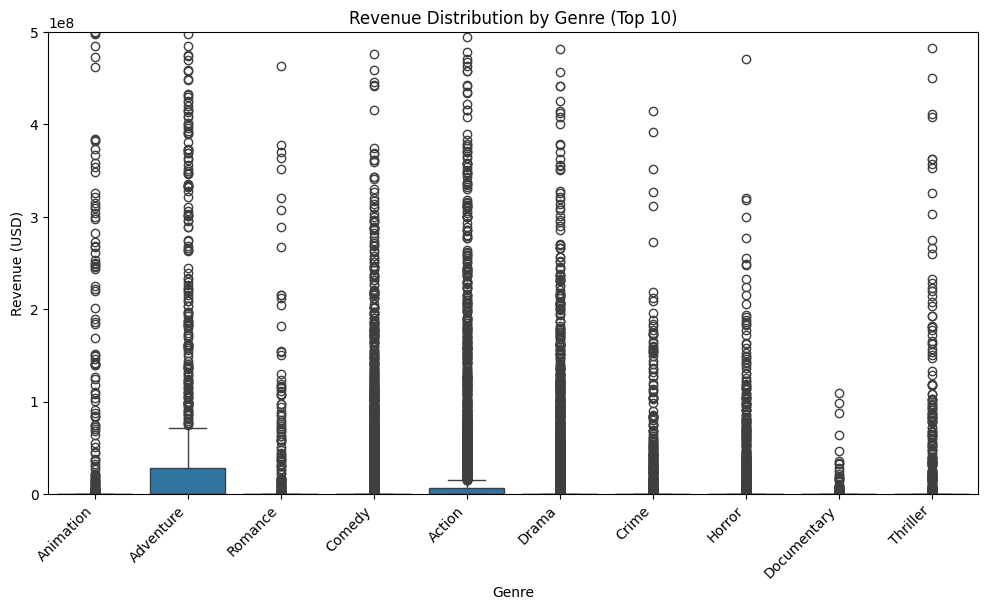

In [36]:
top_genres = movies_full["genres_primary"].value_counts().head(10).index
subset = movies_full[movies_full["genres_primary"].isin(top_genres)]

plt.figure(figsize=(12,6))
sns.boxplot(data=subset, x="genres_primary", y="revenue")
plt.ylim(0, 5e8)  # cap y-axis at 500M for readability
plt.xticks(rotation=45, ha="right")
plt.ylabel("Revenue (USD)")
plt.xlabel("Genre")
plt.title("Revenue Distribution by Genre (Top 10)")
plt.show()


**Analysis**
- Adventure and Action stand out with higher medians and wider spreads — they’re the big money makers.  
- Animation also does well, likely because of global/family appeal.  
- Genres like Drama, Romance, Horror, and Documentary usually bring in less, but still have some breakout hits (outliers).  
- Lots of dots outside the boxes show blockbusters can pop up in almost any genre, though they’re rarer outside Action/Adventure.  
- Overall: Adventure + Action are steady earners and most others are hit-or-miss.


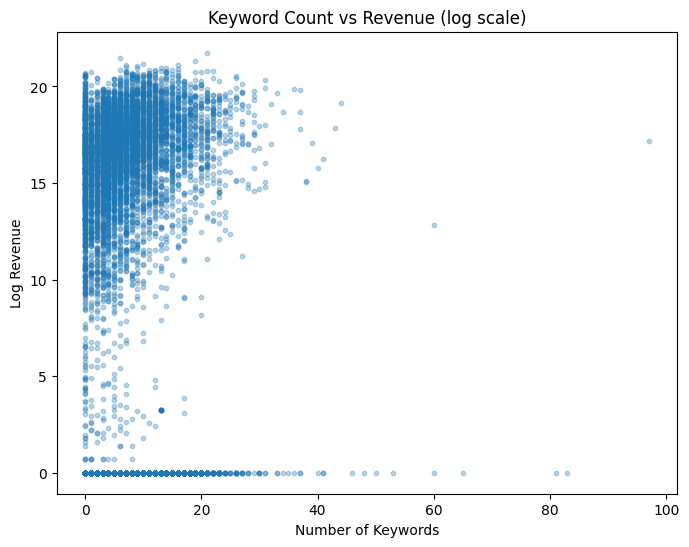

In [42]:
if "num_keywords" in movies_full.columns:
    plt.figure(figsize=(8,6))
    plt.scatter(
        movies_full["num_keywords"],
        np.log1p(movies_full["revenue"]),
        alpha=0.3, s=10
    )
    plt.xlabel("Number of Keywords")
    plt.ylabel("Log Revenue")
    plt.title("Keyword Count vs Revenue (log scale)")
    plt.show()

This plot is mostly just for fun

TMDB: The Movie Database (TMDB)

Google tells me:
> In The Movie Database (TMDb), a keyword refers to a specific term that describes a movie or TV show. These keywords are used to categorize and identify content, making it easier for users to find specific types of movies or shows.

**Analysis**
- Most movies cluster at low keyword counts (< 10), so adding lots of keywords is rare.  
- No clear trend — having more keywords doesn’t necessarily indicate higher revenue.  
- A few outliers have very high revenue exist, but they don’t seem tied to keyword count.  


- Overall: keyword count isn’t a strong predictor of revenue and might just reflect data entry / metadata differences. Also those keywords don't seem to come from the filmmakers/studio necessarily and might just be from the TMDB team or something.


# Findings!



**Research Question:**  
Can we predict the performance of certain movie genres in the future based on performance via ratings and box office revenue of currently released movies?

---

### Key Takeaways from the Data and Visualizations (w.r.t. the dataset which is of movies released before / in July 2017).
- **Top genres over time:**  
  - Drama, Comedy, and Action dominate in terms of number of movies produced.  
  - Action and Adventure are the most profitable genres by average revenue, with blockbuster-level performance continuing to rise.  
  - Documentary appeared in the frequency-based plots, but this is due to dataset artifacts (many low-revenue titles near 2016–2017).

- **Genre profitability vs frequency of production:**  
  - Based on the most common genres made for movies in the dataset, we saw 5 genries (Action, Adventure, Animation, Drama, Comedy) which highlighted that there are genres of movies that don't necessarily make the most money (Drama, Comedy), but still continue to have lots of movies produced.

- **Budget and revenue relationship:**  
  - There is a strong positive relationship that indicates higher budgets generally yield higher revenues.  
     - Makes sense logically. Probably most people wouldn't want to invest in producing a movie that they didn't *think* was going to perform well
  - Blockbuster films with high budgets and revenues are concentrated in Action, Adventure, and Animation.  
  - Low-budget films sometimes achieve strong returns, but these cases are rare and unpredictable at scale.

- **Modeling results:**  
  - The best-performing models (Random Forest, Gradient Boosting) achieved CV R² ≈ 0.59 and Validation R² ≈ 0.49, explaining about half of the variance in revenue.  
    - Some data was captured on the relationship between features and revenue, but it's not very reliable on truly unseen data
  - Prediction errors are large in dollar terms (tens of millions RMSE).  
  - Linear models (Ridge, Lasso, OLS) performed worse, indicating that non-linear models capture genre and budget relationships better.  
  - The models gave some predictive power but not really enough for reliable exact forecasts.

---

### Addressing the Research Question

The results indicate that we can only partially predict the future performance of movie genres. Genre does play a role (ex: Action, Adventure, and Animation consistently outperform others in terms of revenue), which suggests these genres will continue to dominate financially. And, interestingly, this exploration helped me see another angle - budget seeming to be a stronger predictor of financial success than genre (though that's not to say invest a billion dollars in a Romance movie and expect it to perform as well as an Action movie with a billion dollars invested). I believe even more useful insights could be generated on the relationship between budget/genre and revenue to understand further what movies are most likely to perform well (financially).  

Ultimately, the predictive models are limited. The prediction errors are too high to reliably forecast exact future box office performance. Moreover, many external factors of movies are not captured in the dataset - such as marketing, release timing, star power (cast influence/social standing/popularity/etc), political/social recent events, and cultural trends - all of which can strongly influence the outcome. As a result, while we can generalize about which genres are more likely to perform well, we cannot precisely predict the revenue of individual movies.  

---

### Final thoughts

This analysis was conducted on a full dataset of 45,000 movies released during or before July 2017 from the Full MovieLens Dataset. Based on my findings, there are clear trends in genre profitability and production, with Action and Adventure standing out as the strongest financial performers. At the same time, the relationship between budget and revenue suggests that financial success is not driven by genre alone.  

Ultimately, while genre and budget together explain a meaningful portion of revenue variability, movies remain inherently unpredictable. This unpredictability limits the accuracy of detailed forecasts and makes it clear that exact revenue prediction cannot be achieved solely through historical data and genre trends.  

Application: Studios can use these results to understand which genres are financially stronger, but should not rely on models alone for exact revenue forecasting.  
